### SNAP Eligibility Gap and Household Characteristics

## Objective

This analysis explores household-level socioeconomic data with a focus on identifying and understanding the SNAP eligibility gap.

The main goals of this analysis are to:
- Examine low-income households
- Analyze households that are likely eligible for SNAP but not receiving benefits
- Study household composition, including children and elderly presence
- Investigate financial stress indicators such as rent burden

The objective is to better understand the characteristics of underserved and economically vulnerable populations.

In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#load file
df= pd.read_csv("../data/processed/processed_all_households_blind.csv")




In [2]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 61071 entries, 0 to 61070
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SERIALNO                     61071 non-null  str    
 1   PUMA                         61071 non-null  int64  
 2   TARGET_GAP                   61071 non-null  int64  
 3   HAS_ELDERLY                  61071 non-null  int64  
 4   HAS_DISABLED                 61071 non-null  int64  
 5   NUM_CHILDREN                 61071 non-null  int64  
 6   NUM_WORKING_ADULTS           61071 non-null  int64  
 7   MAX_EDUCATION                61071 non-null  float64
 8   IS_MINORITY_HH               61071 non-null  int64  
 9   VEH                          61071 non-null  float64
 10  ACCESSINET                   61071 non-null  float64
 11  GRPIP                        61071 non-null  float64
 12  RMSP                         61071 non-null  float64
 13  NP                         

,PUMA,TARGET_GAP,HAS_ELDERLY,HAS_DISABLED,NUM_CHILDREN,NUM_WORKING_ADULTS,MAX_EDUCATION,IS_MINORITY_HH,VEH,ACCESSINET,...,SMARTPHONE_ONLY,INTERNET_DEVICE_INTERACTION,HOUSING_QUALITY_INDEX,AMENITY_COUNT,LOW_AMENITIES,LIMITED_ENGLISH,ENGLISH_ONLY,PERSONS_PER_ROOM,CROWDED_HH,CHILD_AND_SENIOR_HH
count,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,...,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000,61071.000000
mean,16077.134745,0.080709,0.474382,0.248825,0.473351,1.234629,20.003357,0.402548,1.891814,1.115767,...,0.000557,0.010561,6.283834,0.031210,0.996201,0.023595,0.821519,0.401560,0.001294,0.017783
std,24860.895978,0.272390,0.499347,0.432336,0.926233,0.976882,2.852295,0.490415,1.120146,0.444303,...,0.023589,0.171785,0.586961,0.360905,0.061518,0.151786,0.382920,0.283049,0.035943,0.132161
min,101.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.052632,0.000000,0.000000
25%,1002.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.222222,0.000000,0.000000
50%,5901.000000,0.000000,0.000000,0.000000,0.000000,1.000000,21.000000,0.000000,2.000000,1.000000,...,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.333333,0.000000,0.000000
75%,16101.000000,0.000000,1.000000,0.000000,1.000000,2.000000,22.000000,1.000000,2.000000,1.000000,...,0.000000,0.000000,7.000000,0.000000,1.000000,0.000000,1.000000,0.500000,0.000000,0.000000
max,81003.000000,1.000000,1.000000,1.000000,10.000000,9.000000,24.000000,1.000000,6.000000,3.000000,...,1.000000,3.000000,7.000000,6.000000,1.000000,1.000000,1.000000,7.000000,1.000000,1.000000


### 1. People who receive SNAP


Use ['LOW_INCOME_FLAG==1'] to see how many people receive snap because this dataset does not explicitly indicating SNAP participation.

In [3]:
total_households = len(df)
low_income = df[df['LOW_INCOME_FLAG'] == 1]

print("Total households:", total_households)
print("Low-income households:", len(low_income))
print("Percentage:", len(low_income) / total_households * 100)

Total households: 61071
Low-income households: 22901
Percentage: 37.49897660100538


### 2. Poor People (LOW_INCOME_FLAG)


In [4]:
poor = df[df['LOW_INCOME_FLAG'] == 1]

print("Number of poor households:", len(poor))
print("Percentage:", len(poor) / len(df) * 100)
poor.describe()

Number of poor households: 22901
Percentage: 37.49897660100538


,PUMA,TARGET_GAP,HAS_ELDERLY,HAS_DISABLED,NUM_CHILDREN,NUM_WORKING_ADULTS,MAX_EDUCATION,IS_MINORITY_HH,VEH,ACCESSINET,...,SMARTPHONE_ONLY,INTERNET_DEVICE_INTERACTION,HOUSING_QUALITY_INDEX,AMENITY_COUNT,LOW_AMENITIES,LIMITED_ENGLISH,ENGLISH_ONLY,PERSONS_PER_ROOM,CROWDED_HH,CHILD_AND_SENIOR_HH
count,22901.000000,22901.000000,22901.00000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,...,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000,22901.000000
mean,16552.958211,0.173006,0.50107,0.237937,0.067159,0.724510,19.229859,0.380857,1.236147,1.217763,...,0.000961,0.012925,6.536265,0.033143,0.995721,0.027859,0.881184,0.310116,0.000437,0.002707
std,25640.267289,0.378260,0.50001,0.425830,0.401020,0.726568,3.313608,0.485608,0.870148,0.595654,...,0.030980,0.188556,0.625203,0.380522,0.065278,0.164572,0.323579,0.247219,0.020892,0.051962
min,101.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.052632,0.000000,0.000000
25%,805.000000,0.000000,0.00000,0.000000,0.000000,0.000000,17.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.166667,0.000000,0.000000
50%,1900.000000,0.000000,1.00000,0.000000,0.000000,1.000000,20.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,7.000000,0.000000,1.000000,0.000000,1.000000,0.250000,0.000000,0.000000
75%,16500.000000,0.000000,1.00000,0.000000,0.000000,1.000000,21.000000,1.000000,2.000000,1.000000,...,0.000000,0.000000,7.000000,0.000000,1.000000,0.000000,1.000000,0.333333,0.000000,0.000000
max,81003.000000,1.000000,1.00000,1.000000,9.000000,6.000000,24.000000,1.000000,6.000000,3.000000,...,1.000000,3.000000,7.000000,6.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000


In [25]:
low_income_counts = df['LOW_INCOME_FLAG'].value_counts().sort_index()
low_income_props = df['LOW_INCOME_FLAG'].value_counts(normalize=True).sort_index() * 100

print("Low-Income Household Counts:")
display(low_income_counts)

print("Low-Income Household Percentages:")
display(low_income_props)

Low-Income Household Counts:


LOW_INCOME_FLAG
0    38170
1    22901
Name: count, dtype: int64

Low-Income Household Percentages:


LOW_INCOME_FLAG
0    62.501023
1    37.498977
Name: proportion, dtype: float64

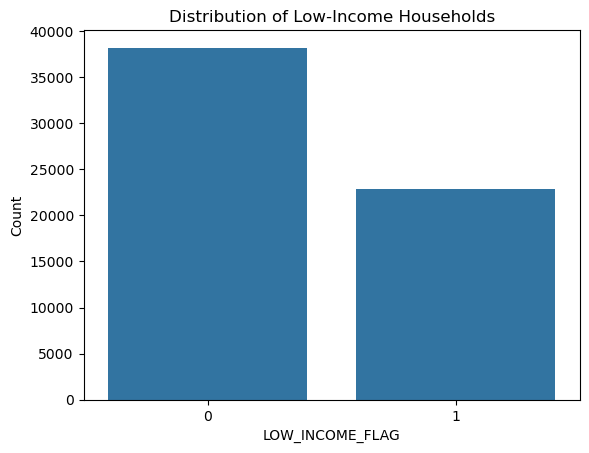

In [26]:
sns.countplot(x='LOW_INCOME_FLAG', data=df)
plt.title("Distribution of Low-Income Households")
plt.xlabel("LOW_INCOME_FLAG")
plt.ylabel("Count")
plt.show()

## Low-Income Household Analysis

The variable `LOW_INCOME_FLAG` is used in this notebook to examine low-income households within the final blind dataset.

Although `TARGET_GAP` was constructed upstream using poverty-based eligibility and SNAP receipt, `LOW_INCOME_FLAG` remains useful for comparing broader income-related differences across households.

### 3. People qualified for SNAP but NOT receiving it --> We will use TARGET_GAP == 1.
 

In [6]:
gap = df[df['TARGET_GAP'] == 1]

print("Eligible but NOT receiving SNAP:", len(gap))
print("Percentage:", len(gap) / len(df) * 100)

Eligible but NOT receiving SNAP: 4929
Percentage: 8.070933831114605


Compare with poor:

How many poor households are missing SNAP?

                  SNAP VS POVERTY

In [7]:
pd.crosstab(df['LOW_INCOME_FLAG'], df['TARGET_GAP'], normalize='index')

TARGET_GAP,0,1
LOW_INCOME_FLAG,,
0,0.974666,0.025334
1,0.826994,0.173006


### 4.Households eligible for SNAP but NOT receiving it
#### SNAP Eligibility Gap Analysis


In [8]:
gap = df[df['TARGET_GAP'] == 1]

gap.describe()

,PUMA,TARGET_GAP,HAS_ELDERLY,HAS_DISABLED,NUM_CHILDREN,NUM_WORKING_ADULTS,MAX_EDUCATION,IS_MINORITY_HH,VEH,ACCESSINET,...,SMARTPHONE_ONLY,INTERNET_DEVICE_INTERACTION,HOUSING_QUALITY_INDEX,AMENITY_COUNT,LOW_AMENITIES,LIMITED_ENGLISH,ENGLISH_ONLY,PERSONS_PER_ROOM,CROWDED_HH,CHILD_AND_SENIOR_HH
count,4929.000000,4929.0,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,...,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000,4929.000000
mean,17644.400487,1.0,0.546155,0.330087,0.353621,0.569892,18.192331,0.444106,1.405559,1.328667,...,0.002029,0.017042,6.403124,0.051735,0.993305,0.051938,0.812741,0.402675,0.001826,0.012781
std,25654.572020,0.0,0.497916,0.470292,0.898528,0.767408,3.602445,0.496916,1.040601,0.710765,...,0.045001,0.215364,0.680490,0.477541,0.081557,0.221923,0.390159,0.326475,0.042696,0.112342
min,101.000000,1.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.052632,0.000000,0.000000
25%,1003.000000,1.0,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.200000,0.000000,0.000000
50%,5908.000000,1.0,1.000000,0.000000,0.000000,0.000000,19.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.333333,0.000000,0.000000
75%,17700.000000,1.0,1.000000,1.000000,0.000000,1.000000,21.000000,1.000000,2.000000,1.000000,...,0.000000,0.000000,7.000000,0.000000,1.000000,0.000000,1.000000,0.500000,0.000000,0.000000
max,81003.000000,1.0,1.000000,1.000000,8.000000,6.000000,24.000000,1.000000,6.000000,3.000000,...,1.000000,3.000000,7.000000,6.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000


In [9]:
df['TARGET_GAP'].value_counts(normalize=True)

TARGET_GAP
0    0.919291
1    0.080709
Name: proportion, dtype: float64

### Characteristics of Gap Households

Descriptive statistics for households with `TARGET_GAP = 1` show the overall profile of the SNAP gap population. These households can be examined in terms of income, rent burden, number of children, elderly presence, disability, and work participation.

This summary helps identify whether the gap population is associated with financial strain and other forms of household vulnerability.

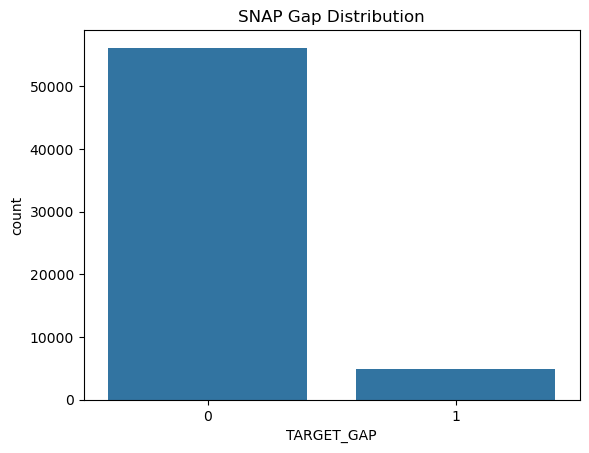

In [10]:
sns.countplot(x='TARGET_GAP', data=df)
plt.title("SNAP Gap Distribution")
plt.show()

In [11]:
df['TARGET_GAP'].value_counts(normalize=True)

TARGET_GAP
0    0.919291
1    0.080709
Name: proportion, dtype: float64

###  SNAP Gap Analysis

Approximately 8% of households are eligible for SNAP but are not receiving benefits.  
This represents a critical gap in assistance programs.

### 5.Group Comparison (Gap vs Non-Gap)

In [30]:
gap_comparison = df.groupby('TARGET_GAP')[[
    'NUM_CHILDREN',
    'HAS_ELDERLY',
    'HAS_DISABLED',
    'NUM_WORKING_ADULTS',
    'LOG_INCOME',
    'RENT_BURDEN',
    'POVERTY_GAP',
    'HOUSEHOLD_PRESSURE'
]].mean()

display(gap_comparison)

,NUM_CHILDREN,HAS_ELDERLY,HAS_DISABLED,NUM_WORKING_ADULTS,LOG_INCOME,RENT_BURDEN,POVERTY_GAP,HOUSEHOLD_PRESSURE
TARGET_GAP,,,,,,,,
0,0.483862,0.468081,0.241691,1.292989,7.885230,0.038438,-264.868405,1.27414
1,0.353621,0.546155,0.330087,0.569892,3.291046,0.274498,65.185636,1.48333


###  Gap vs Non-Gap Comparison

Comparing households by `TARGET_GAP` helps reveal how gap households differ from the rest of the sample.

In general, households in the SNAP gap tend to have:
- lower income
- higher rent burden
- greater signs of economic stress

This supports the interpretation that the gap population is financially vulnerable and potentially underserved.

In [28]:
gap = df[df['TARGET_GAP'] == 1]
non_gap = df[df['TARGET_GAP'] == 0]

print("Gap households:", len(gap))
print("Non-gap households:", len(non_gap))

Gap households: 4929
Non-gap households: 56142


### 6.Housing Stress Analysis

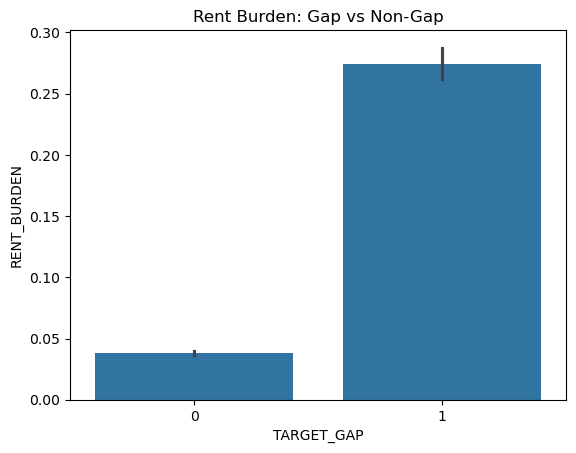

In [13]:
sns.barplot(x='TARGET_GAP', y='RENT_BURDEN', data=df)
plt.title("Rent Burden: Gap vs Non-Gap")
plt.show()

### Housing Burden

Households in the SNAP gap experience significantly higher rent burden, 
indicating increased financial stress and housing instability.

### 7. Children Analysis
#### Average number of children per household

In [32]:
avg_children = df['NUM_CHILDREN'].mean()
print("Average number of children per household:", avg_children)

Average number of children per household: 0.473350690180282


In [15]:
df['NUM_CHILDREN'].describe()

count    61071.000000
mean         0.473351
std          0.926233
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         10.000000
Name: NUM_CHILDREN, dtype: float64

# Do poor households have more children?

##### By income group:

In [16]:
df.groupby('LOW_INCOME_FLAG')['NUM_CHILDREN'].mean()

LOW_INCOME_FLAG
0    0.717055
1    0.067159
Name: NUM_CHILDREN, dtype: float64

In [17]:
df['LOW_INCOME_FLAG'].value_counts()

LOW_INCOME_FLAG
0    38170
1    22901
Name: count, dtype: int64

In [18]:
df.groupby('LOW_INCOME_FLAG')['LOG_INCOME'].mean()

LOW_INCOME_FLAG
0    11.732717
1     0.483662
Name: LOG_INCOME, dtype: float64

###  Children and Household Structure

The average number of children per household provides an additional view of household composition. When comparing income groups, the results suggest that low-income households in this dataset may have fewer children on average than expected.

This pattern should be interpreted together with elderly presence and other demographic factors, since poverty in this dataset may be linked to older or smaller households rather than larger family size alone.

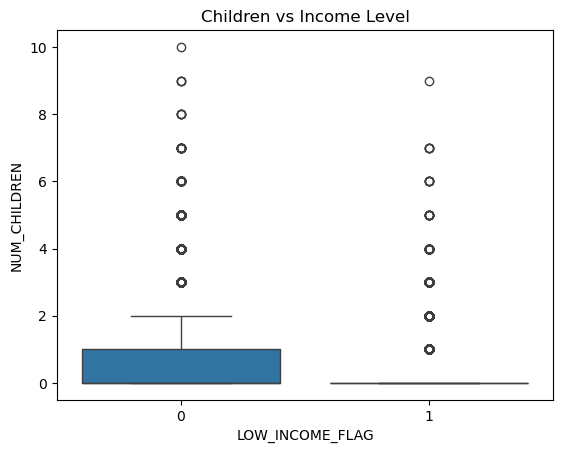

In [19]:
sns.boxplot(x='LOW_INCOME_FLAG', y='NUM_CHILDREN', data=df)
plt.title("Children vs Income Level")
plt.show()

### 8.Elderly Analysis

In [20]:
df.groupby('LOW_INCOME_FLAG')['HAS_ELDERLY'].mean()

LOW_INCOME_FLAG
0    0.45837
1    0.50107
Name: HAS_ELDERLY, dtype: float64

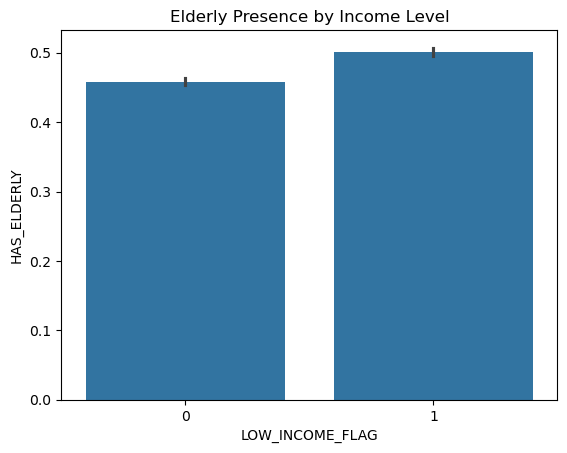

In [21]:
sns.barplot(x='LOW_INCOME_FLAG', y='HAS_ELDERLY', data=df)
plt.title("Elderly Presence by Income Level")
plt.show()

### Elderly Presence

The analysis shows that elderly presence is an important dimension of household vulnerability. A higher share of elderly households among low-income or gap households may help explain why some groups have fewer children while still experiencing financial hardship.

This suggests that economic vulnerability in the dataset is not limited to households with children, but also includes aging households.

### 9. Poverty and gap cross-tab

In [33]:
poverty_gap_table = pd.crosstab(
    df['LOW_INCOME_FLAG'],
    df['TARGET_GAP'],
    normalize='index'
)

display(poverty_gap_table)

TARGET_GAP,0,1
LOW_INCOME_FLAG,,
0,0.974666,0.025334
1,0.826994,0.173006


### 10. Income Distribution

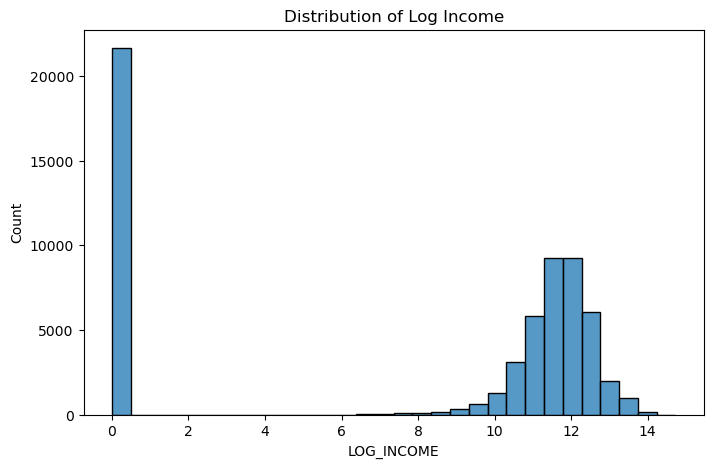

In [34]:
plt.figure(figsize=(8, 5))
sns.histplot(df['LOG_INCOME'], bins=30)
plt.title("Distribution of Log Income")
plt.xlabel("LOG_INCOME")
plt.ylabel("Count")
plt.show()

### 11. Correlation Heatmap

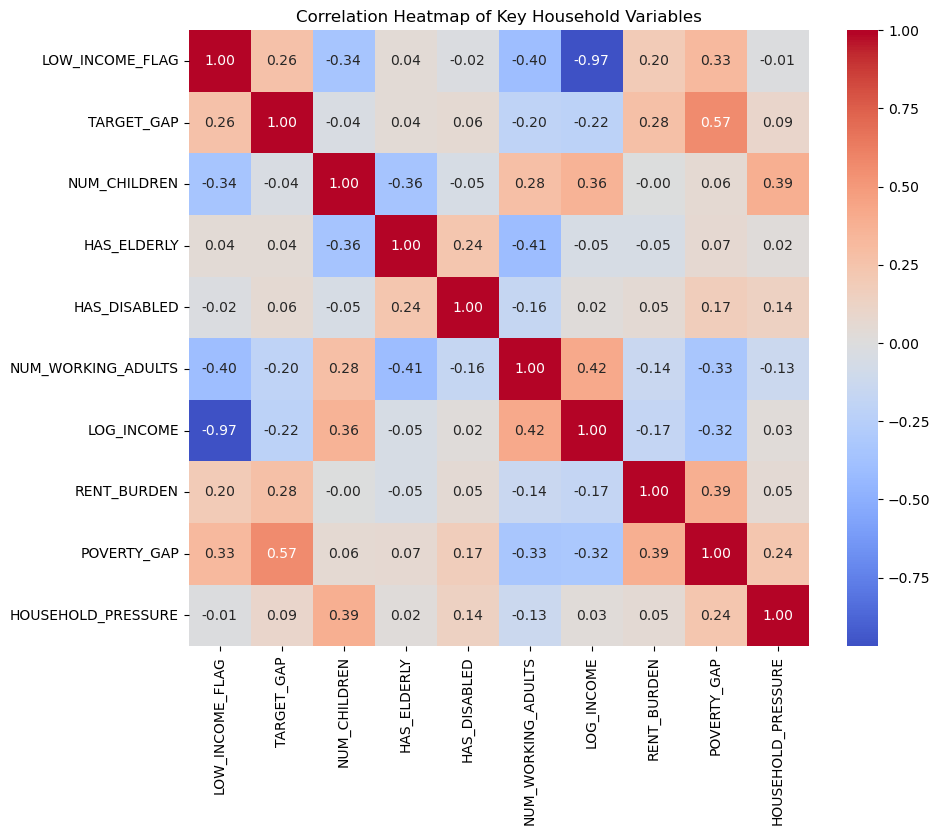

In [22]:

cols = [
    'LOW_INCOME_FLAG', 'TARGET_GAP', 'NUM_CHILDREN', 'HAS_ELDERLY',
    'HAS_DISABLED', 'NUM_WORKING_ADULTS', 'LOG_INCOME',
    'RENT_BURDEN', 'POVERTY_GAP', 'HOUSEHOLD_PRESSURE'
]

corr_matrix = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation Heatmap of Key Household Variables")
plt.show()

###  Explain Correlation Map

The correlation heatmap highlights the strongest relationships among income, poverty-related indicators, housing burden, and household composition.

Key patterns suggest that:
- lower income is closely associated with low-income status
- SNAP gap households are associated with higher poverty-related stress
- rent burden is positively related to economic hardship
- elderly presence and number of children reflect different household structures

Overall, the correlation analysis supports the conclusion that households in the SNAP gap face meaningful socioeconomic disadvantage.

### 12.Data Limitation



The final blind dataset does not include the original raw variables for SNAP receipt (`FS`) or poverty ratio (`POVPIP`). However, the variable `TARGET_GAP` was created before blinding using those upstream fields.

Specifically, `TARGET_GAP = 1` was defined using eligibility-related poverty status together with non-receipt of SNAP. Therefore, the gap analysis in this notebook is based on a constructed target derived from original SNAP and poverty information, rather than a purely indirect proxy.

### 13.Final Conclusion

This exploratory analysis identifies an important group of households that fall into the SNAP eligibility gap, represented by `TARGET_GAP = 1`. These households were defined upstream as likely eligible for SNAP based on poverty-related criteria but not receiving benefits.

The results suggest that gap households experience clear socioeconomic disadvantage, including lower income and greater housing burden. The analysis also shows that household vulnerability may take different forms, including elderly presence and smaller household structure.

Overall, the findings highlight the importance of understanding not only poverty, but also program non-participation among households that may qualify for assistance.